# **Instalações e Importações**

In [ ]:
%%capture

# Instalações
!pip install lifelines shap optuna cmaes scikit-survival

In [ ]:
# Imports
seed = 1

import os
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

from scipy.interpolate import interp1d

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.metrics import roc_curve, roc_auc_score, auc, ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

from sksurv.ensemble import RandomSurvivalForest
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.svm import FastSurvivalSVM
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw, brier_score
from sksurv.nonparametric import kaplan_meier_estimator

from lifelines.statistics import logrank_test
from lifelines import KaplanMeierFitter

import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler

import shap

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

In [ ]:
!gdown 1lxX475yHCUDG1rR5aJ30mQrOeGvIEQ6a

with open('colorretal.pkl', 'rb') as f:
    colo = pickle.load(f)

colo

Downloading...
From (original): https://drive.google.com/uc?id=1lxX475yHCUDG1rR5aJ30mQrOeGvIEQ6a
From (redirected): https://drive.google.com/uc?id=1lxX475yHCUDG1rR5aJ30mQrOeGvIEQ6a&confirm=t&uuid=8bee2832-4f78-470c-a632-00c64ba4ab3b
To: /content/colorretal.pkl
100% 114M/114M [00:02<00:00, 38.6MB/s]


{'rsf': RandomSurvivalForest(bootstrap=False, max_depth=10, max_features='log2',
                      min_samples_leaf=9, min_samples_split=9, n_estimators=116,
                      random_state=1),
 'gb': GradientBoostingSurvivalAnalysis(learning_rate=0.2, max_depth=5,
                                  max_features=0.5, min_samples_leaf=6,
                                  min_samples_split=5, n_estimators=111,
                                  random_state=1, subsample=0.9),
 'ssvm': FastSurvivalSVM(optimizer='avltree', random_state=1),
 'xgb_cox': <xgboost.core.Booster at 0x78fbb98abec0>,
 'xgb_aft': <xgboost.core.Booster at 0x78fbb98c00b0>}

# **Funções**

In [ ]:
# Importação das funções
!gdown 1-uw7N4Vx5eNLso_NQ64uObFTlwXhdnda --quiet

from functions_ml_survival import *

In [ ]:
#######################################################################################

def train_preprocessing(df, ohe_encoder=None, normalizer='StandardScaler'):
    """
    Performs preprocessing on the training dataset.

    Args:
        df (pandas.DataFrame): The DataFrame to be preprocessed.
        ohe_encoder (list, optional): A list of columns to apply one-hot encoding. If None,
            all categorical columns will be encoded using LabelEncoder.
        normalizer (str, optional): The type of normalization to apply. Defaults to 'StandardScaler'.
            Options include: 'StandardScaler', 'MinMaxScaler', 'MaxAbsScaler', 'QuantileTransformer'.

    Returns:
        tuple: A tuple containing:
            - df_aux (pandas.DataFrame): The preprocessed DataFrame.
            - enc (dict): A dictionary of encoders, one for each categorical variable.
            - norm: The normalization object used.
            - feat_cols (list): A list of feature column names.
    """

    df_aux = df.copy()

    enc = {}  # Dictionary to store encoders
    if ohe_encoder != None:
        # Apply one-hot encoding to specified columns
        for col in ohe_encoder:
            enc[col] = OneHotEncoder(handle_unknown='ignore', drop='first')
            ohe_results = enc[col].fit_transform(df_aux[[col]])
            df1 = pd.DataFrame(ohe_results.toarray(),
                               columns=enc[col].get_feature_names_out(),
                               index=df_aux[col].index)
            df_aux = df_aux.merge(df1, how='left', left_index=True, right_index=True)

        df_aux.drop(columns=ohe_encoder, inplace=True)

    # Apply label encoding to remaining categorical columns
    list_categorical = df_aux.select_dtypes(include='object').columns
    for col in list_categorical:
        enc[col] = LabelEncoder()
        df_aux[col] = enc[col].fit_transform(df_aux[col])

    # Select feature columns
    feat_cols = df_aux.columns

    # Apply normalization
    if normalizer == 'StandardScaler':
        norm = StandardScaler()
    elif normalizer == 'MinMaxScaler':
        norm = MinMaxScaler((0, 1))
    elif normalizer == 'MaxAbsScaler':
        norm = MaxAbsScaler()
    elif normalizer == 'QuantileTransformer':
        norm = QuantileTransformer(output_distribution='normal')

    df_aux = norm.fit_transform(df_aux)

    return df_aux, enc, norm, feat_cols

#######################################################################################

def test_preprocessing(df, enc, norm, ohe_encoder=None):
    """
    Performs preprocessing on the test dataset using the provided encoders and normalizer.

    Args:
        df (pandas.DataFrame): The DataFrame to be preprocessed.
        enc (dict): A dictionary of encoders used for categorical features in the training set.
        norm: The normalization object used for the training set.
        ohe_encoder (list, optional): A list of columns to apply one-hot encoding. If None,
            all categorical columns will be encoded using LabelEncoder.

    Returns:
        pandas.DataFrame: The preprocessed DataFrame.
    """

    df_aux = df.copy()

    if ohe_encoder:
        # Apply one-hot encoding to specified columns using pre-trained encoders
        for col in ohe_encoder:
            ohe_results = enc[col].transform(df_aux[[col]])
            df1 = pd.DataFrame(ohe_results.toarray(),
                               columns=enc[col].get_feature_names_out(),
                               index=df_aux[col].index)
            df_aux = df_aux.merge(df1, how='left', left_index=True, right_index=True)

        df_aux.drop(columns=ohe_encoder, inplace=True)

    # Apply label encoding to remaining categorical columns
    # Handle unseen categories by assigning them a new category (e.g., -1)
    list_categorical = df_aux.select_dtypes(include='object').columns
    for col in list_categorical:
        df_aux.loc[~df_aux[col].isin(enc[col].classes_), col] = -1
        df_aux.loc[df_aux[col].isin(enc[col].classes_), col] = enc[col].transform(df_aux[col][df_aux[col].isin(enc[col].classes_)])

    # Apply normalization using the pre-trained scaler
    df_aux = norm.transform(df_aux)

    return df_aux

#######################################################################################

def preprocessing_clf(x_train, x_test, ohe_encoder=None,
                      norm_name='StandardScaler', return_enc_norm=False,
                      random_state=0):
    """
    Performs comprehensive data preprocessing, including train-test split,
    categorical encoding, normalization, and optional class balancing.

    Args:
        x_train: The DataFrame containing the train data.
        x_test: The DataFrame containing the test data.
        ohe_encoder: A list of columns for one-hot encoding.
        norm_name: The name of the normalizer to use.
        return_enc_norm: Whether to return the encoders and normalizer.
        random_state: Random seed for reproducibility.

    Returns:
        A tuple containing:
            - X_train_enc: Preprocessed training features.
            - X_test_: Preprocessed testing features.
            - feat_cols: Feature column names after preprocessing.
            - enc (optional): Dictionary of encoders used.
            - norm (optional): Normalization object used.
    """
    # Preprocess training set
    X_train_enc, enc, norm, feat_cols = train_preprocessing(x_train, ohe_encoder=ohe_encoder,
                                                            normalizer=norm_name)
    # Preprocess testing set using the same encoders and normalizer
    X_test_ = test_preprocessing(x_test, enc, norm, ohe_encoder=ohe_encoder)

    # Print shapes for verification
    print(f'X_train = {X_train_enc.shape}, X_test = {X_test_.shape}')

    # Return results
    if return_enc_norm:
        return X_train_enc, X_test_, feat_cols, enc, norm
    else:
        return X_train_enc, X_test_, feat_cols

#######################################################################################

def plot_roc_curve(model, X_train, X_test, y_train, y_test):
    """
    Plots the Receiver Operating Characteristic (ROC) curve for a classification model,
    calculating the Area Under the Curve (AUC) for both training and testing sets.

    Args:
        model: A trained classification model with a `predict_proba` method.
        X_train: Training features.
        X_test: Testing features.
        y_train: Training labels.
        y_test: Testing labels.

    Returns:
        None: Displays the ROC curve plot.
    """

    # Get predicted probabilities for positive class
    probas_train = model.predict_proba(X_train)[:, 1]
    probas_test = model.predict_proba(X_test)[:, 1]

    # Calculate true positive rate (TPR) and false positive rate (FPR)
    fp_train, tp_train, _ = roc_curve(y_train, probas_train)
    fp_test, tp_test, _ = roc_curve(y_test, probas_test)

    # Calculate AUC
    auc_train = auc(fp_train, tp_train)
    auc_test = auc(fp_test, tp_test)

    # Plot ROC curves
    plt.figure(figsize=(10, 7))
    plt.plot(fp_train, tp_train, 'b', label=f'Train (AUC = {auc_train:.4f})')
    plt.plot(fp_test, tp_test, 'r', label=f'Test (AUC = {auc_test:.4f})')

    # Plot random guessing line
    plt.plot(np.linspace(0, 1, 100),
             np.linspace(0, 1, 100),
             label='Baseline',
             linestyle='--',
             color='k')

    # Set plot labels and display
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.grid(True)
    plt.legend()
    plt.show()

#######################################################################################

def plot_confusion_matrix(model, x, y, format='.5f', norm=True):
    """
    Plots a normalized confusion matrix and classification report for a given model.

    Args:
        model: A trained classification model.
        x: The features of the test set.
        y: The true labels of the test set.
        format (str, optional): Format specifier for the values in the confusion matrix.
            Defaults to '.5f' (5 decimal places).
        norm (bool, optional): If True, normalizes the confusion matrix. Defaults to True.

    Returns:
        None: Displays the confusion matrix and classification report.
    """

    # Create a confusion matrix plot
    with plt.rc_context({'font.size': 12, 'font.weight': 'bold'}):
        if norm:
            # Plot a normalized confusion matrix
            ConfusionMatrixDisplay.from_estimator(model, x, y, values_format=format,
                                                 cmap='binary', normalize='true')
        else:
            # Plot a non-normalized confusion matrix
            ConfusionMatrixDisplay.from_estimator(model, x, y, cmap='binary',
                                                 values_format='.0f')
        plt.show()

    # Generate a classification report
    pred = model.predict(x)
    print(f'\n{classification_report(y, pred, digits=5)}')

#######################################################################################

def plot_shap_values(model, x, features, max_display=10):
    """
    Plots a summary plot of SHAP values to visualize feature importance.

    Args:
        model: A trained machine learning model.
        x: A pandas DataFrame containing the features used to train the model.
        features: A list of feature names.
        max_display: The maximum number of features to display in the plot.

    Returns:
        None: Displays the SHAP summary plot.
    """

    # Calculate SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x)

    # Plot summary plot
    try:
        # For models with multiple outputs
        shap.summary_plot(shap_values[1], x, feature_names=features, max_display=max_display)
    except AssertionError:
        # For models with a single output
        shap.summary_plot(shap_values, x, feature_names=features, max_display=max_display)

#######################################################################################

# **Modelos de Classificação**

## **Sobrevida de 1 ano**

In [ ]:
# Dataset de câncer colorretal
!gdown 1yzI52UDZyac0QGWmKL5Mai1JOqWUTeMQ --quiet

In [ ]:
# Leitura dos dados
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)  # Dimensões do conjunto de dados
df_colo.head(3)  # 3 primeiras linhas do conjunto de dados

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
# Remove os casos com status de sobrevida desconhecido.
# São excluídos os indivíduos que não apresentaram óbito (obito_geral = 0)
# e também não foram classificados como sobreviventes no primeiro ano
# (sobrevida_ano1 = 0).
df_colo = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano1 == 0))].reset_index(drop=True)

# Exibe as dimensões do DataFrame após a remoção dos casos
# com status de sobrevida desconhecido
df_colo.shape

(41638, 49)

In [ ]:
# Distribuição dos dados de óbito por qualquer razão
df_colo['obito_geral'].value_counts()

,count
obito_geral,
1,21877
0,19761


In [ ]:
# Divisão dos dados em treino e teste
# Separação das features (X) e label (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (todas as colunas, exceto 'obito_geral')
y = df_colo['obito_geral']  # Label ('obito_geral')

# Divisão do conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% treino, 20% teste
                                                    random_state=seed,  # Reprodutibilidade
                                                    stratify=y)  # Estratificação para manter a proporção das classes

# Tamanhos dos conjuntos após a divisão dos dados
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (33310, 48)
y_train: (33310,)
X_test: (8328, 48)
y_test: (8328,)


In [ ]:
# Salvamento dos datasets
# Cancatenação das features e label
df_treino = pd.concat([X_train, y_train], axis=1)  # Combinação do X_train e y_train em um conjunto de dados
df_teste = pd.concat([X_test, y_test], axis=1)  # Combinação do X_test e y_test em um conjunto de dados

df_treino.to_csv('colorretal_treino.csv', index=False)  # Salva o dataset de treino como 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Salva o dataset de teste como 'colorretal_teste.csv'

In [ ]:
# Leitura dos dados de treino
df_treino = pd.read_csv('colorretal_treino.csv')
print(df_treino.shape)  # Dimensão dos dados
df_treino.head(3)  # 3 primeiras linhas do conjunto de dados

(33310, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,270877,4,31,2,3552205,2,2,C187,IVA,IV,...,0,2,1,0,0,1,1,1,61,0
1,16624,3,67,2,3550308,2,2,C182,IIIB,III,...,3,3,0,0,1,0,0,0,2,1
2,20737,2,80,2,3512001,9,2,C209,IIA,II,...,2,2,0,0,0,1,0,0,17,1


In [ ]:
# Leitura dos dados de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensão dos dados
df_teste.head(3)  # 3 primeiras linhas do conjunto de dados

(8328, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,22128,5,37,2,3549805,2,1,C185,IV,IV,...,2,2,1,1,1,1,1,0,51,1
1,740092,3,70,2,3542404,2,2,C182,I,I,...,0,1,0,0,0,1,0,0,17,0
2,21768,4,61,2,3539004,9,1,C209,III,III,...,2,2,0,0,1,1,0,0,15,1


In [ ]:
# Exclusão das linhas com ULTIDIAG negativo
df_treino = df_treino[df_treino.ULTIDIAG >= 0]

df_treino.shape

(33310, 49)

In [ ]:
# Retirada das colunas que não serão utilizadas como features nos modelos de sobrevida
list_drop = ['ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3',
             'sobrevida_ano5', 'meses_diag', 'obito_geral']

X_train_1year = df_treino.drop(list_drop, axis=1)  # Conjunto de treino
y_train_1year = df_treino.sobrevida_ano1.copy()

X_test_1year = df_teste.drop(list_drop, axis=1)  # Conjunto de teste
y_test_1year = df_teste.sobrevida_ano1.copy()

X_train_1year.shape, y_train_1year.shape, X_test_1year.shape, y_test_1year.shape

((33310, 16), (33310,), (8328, 16), (8328,))

In [ ]:
# Pré-processamento dos conjuntos de treino e teste
X_train_1year, X_test_1year, feat_cols_1year, enc, norm = preprocessing_clf(
    X_train_1year, X_test_1year,
    norm_name='StandardScaler',  # Método de normalização
    return_enc_norm=True,  # Retornar os modelos de codificação e normalização
    random_state=seed)  # Reprodutibilidade

X_train = (33310, 16), X_test = (8328, 16)


### **XGBoost**


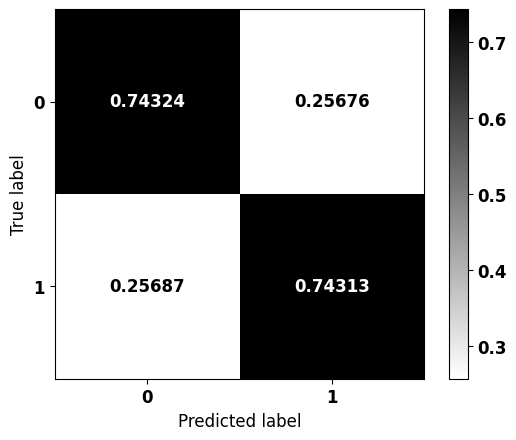


              precision    recall  f1-score   support

           0    0.48306   0.74324   0.58555      2033
           1    0.89962   0.74313   0.81392      6295

    accuracy                        0.74316      8328
   macro avg    0.69134   0.74318   0.69973      8328
weighted avg    0.79793   0.74316   0.75817      8328



In [ ]:
# Treina o modelo XGBoost final utilizando os melhores hiperparâmetros
# identificados durante o processo de otimização
params = {
    'n_estimators': 114,       # Número de árvores utilizadas no modelo
    'max_depth': 4,            # Profundidade máxima das árvores
    'learning_rate': 0.2,      # Taxa de aprendizado do modelo
    'gamma': 0.2,              # Redução mínima da função de perda necessária para dividir um nó
    'min_child_weight': 3,     # Soma mínima dos pesos das observações em um nó filho
    'colsample_bytree': 0.4,   # Proporção de variáveis selecionadas para cada árvore
    'random_state': 1,         # Semente aleatória para garantir reprodutibilidade
    'scale_pos_weight': 0.3004 # Peso aplicado à classe positiva para lidar com o desbalanceamento
}

# Inicializa o classificador XGBoost
xgb_1year = XGBClassifier()

# Define os hiperparâmetros otimizados no modelo
xgb_1year.set_params(**params)

# Treina o modelo otimizado utilizando o conjunto de treinamento
# correspondente à classificação de sobrevida em 1 ano
xgb_1year.fit(X_train_1year, y_train_1year)

# Gera e exibe a matriz de confusão para avaliar o desempenho
# do modelo no conjunto de teste
plot_confusion_matrix(xgb_1year, X_test_1year, y_test_1year)

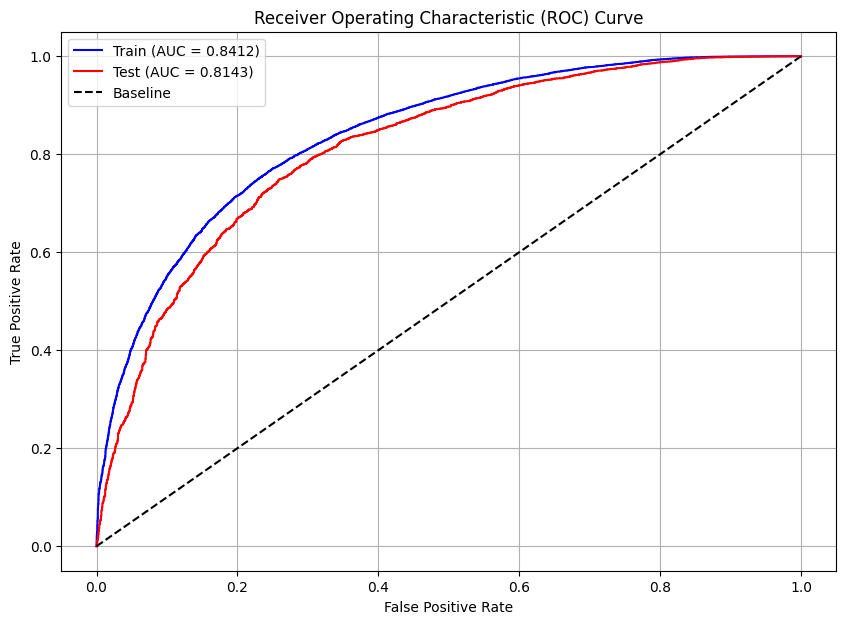

In [ ]:
# Curva ROC
plot_roc_curve(xgb_1year, X_train_1year, X_test_1year, y_train_1year, y_test_1year)

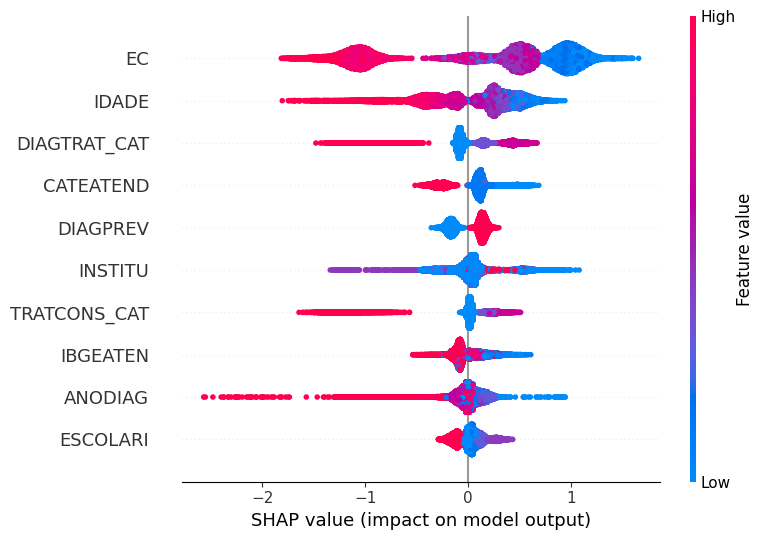

In [ ]:
# Importância das features pelo SHAP
plot_shap_values(xgb_1year, X_train_1year, feat_cols_1year)

## **Sobrevida de 3 anos**

In [ ]:
# Dataset de câncer colorretal
!gdown 1yzI52UDZyac0QGWmKL5Mai1JOqWUTeMQ --quiet

In [ ]:
# Leitura dos dados
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)  # Dimensões do conjunto de dados
df_colo.head(3)  # 3 primeiras linhas do conjunto de dados

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
# Remove os casos com status de sobrevida desconhecido.
# São excluídos os indivíduos que não apresentaram óbito (obito_geral = 0)
# e também não foram classificados como sobreviventes no terceiro ano
# (sobrevida_ano3 = 0).
df_colo = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano3 == 0))].reset_index(drop=True)

# Exibe as dimensões do DataFrame após a remoção dos casos
# com status de sobrevida desconhecido
df_colo.shape

(36895, 49)

In [ ]:
# Divisão dos dados em treino e teste
# Separação das features (X) e label (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (todas as colunas, exceto 'obito_geral')
y = df_colo['obito_geral']  # Label ('obito_geral')

# Divisão do conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% treino, 20% teste
                                                    random_state=seed,  # Reprodutibilidade
                                                    stratify=y)  # Estratificação para manter a proporção das classes

# Tamanhos dos conjuntos após a divisão dos dados
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (29516, 48)
y_train: (29516,)
X_test: (7379, 48)
y_test: (7379,)


In [ ]:
# Salvamento dos datasets
# Cancatenação das features e label
df_treino = pd.concat([X_train, y_train], axis=1)  # Combinação do X_train e y_train em um conjunto de dados
df_teste = pd.concat([X_test, y_test], axis=1)  # Combinação do X_test e y_test em um conjunto de dados

df_treino.to_csv('colorretal_treino.csv', index=False)  # Salva o dataset de treino como 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Salva o dataset de teste como 'colorretal_teste.csv'

In [ ]:
# Leitura dos dados de treino
df_treino = pd.read_csv('colorretal_treino.csv')
print(df_treino.shape)  # Dimensão dos dados
df_treino.head(3)  # 3 primeiras linhas do conjunto de dados

(29516, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,20141,2,67,2,3525904,2,2,C209,II,II,...,1,2,0,0,0,0,0,0,7,1
1,8672,9,70,1,3550308,9,1,C187,IV,IV,...,0,0,1,0,1,0,0,0,6,1
2,16772,9,75,1,3550308,9,1,C187,IV,IV,...,2,0,1,0,0,1,0,0,14,1


In [ ]:
# Leitura dos dados de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensão dos dados
df_teste.head(3)  # 3 primeiras linhas do conjunto de dados

(7379, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,8672,3,47,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,1,1,1,61,0
1,208259,4,60,1,3548807,2,2,C209,III,III,...,0,0,0,0,0,1,1,0,47,0
2,18597,9,62,2,3548500,9,1,C209,III,III,...,0,0,0,0,1,0,0,0,5,1


In [ ]:
# Exclusão das linhas com ULTIDIAG negativo
df_treino = df_treino[df_treino.ULTIDIAG >= 0]

df_treino.shape

(29516, 49)

In [ ]:
# Retirada das colunas que não serão utilizadas como features nos modelos de sobrevida
list_drop = ['ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3',
             'sobrevida_ano5', 'meses_diag', 'obito_geral']

X_train_3year = df_treino.drop(list_drop, axis=1)  # Conjunto de treino
y_train_3year = df_treino.sobrevida_ano3.copy()

X_test_3year = df_teste.drop(list_drop, axis=1)  # Conjunto de teste
y_test_3year = df_teste.sobrevida_ano3.copy()

X_train_3year.shape, y_train_3year.shape, X_test_3year.shape, y_test_3year.shape

((29516, 16), (29516,), (7379, 16), (7379,))

In [ ]:
# Pré-processamento dos conjuntos de treino e teste
X_train_3year, X_test_3year, feat_cols_3year, enc, norm = preprocessing(
    X_train_3year, X_test_3year,
    norm_name='StandardScaler',  # Método de normalização
    return_enc_norm=True,  # Retornar os modelos de codificação e normalização
    random_state=seed)  # Reprodutibilidade

### **XGBoost**


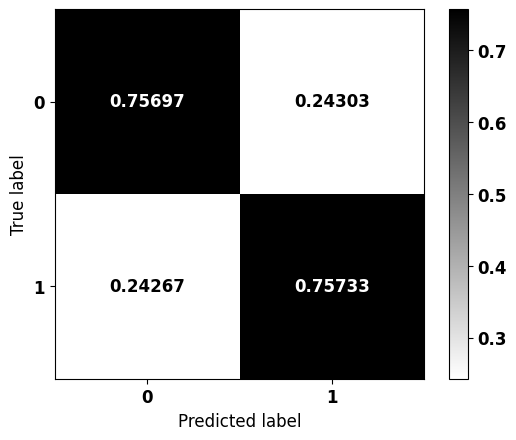


              precision    recall  f1-score   support

           0    0.76106   0.75697   0.75901      3728
           1    0.75320   0.75733   0.75526      3651

    accuracy                        0.75715      7379
   macro avg    0.75713   0.75715   0.75713      7379
weighted avg    0.75717   0.75715   0.75715      7379



In [ ]:
# Define os melhores hiperparâmetros identificados durante o processo
# de otimização para o modelo de classificação de sobrevida em 3 anos
params = {
    'n_estimators': 150,        # Número de árvores utilizadas no modelo
    'max_depth': 5,             # Profundidade máxima das árvores
    'learning_rate': 0.2,       # Taxa de aprendizado do modelo
    'gamma': 0.1,               # Redução mínima da função de perda necessária para dividir um nó
    'min_child_weight': 1,      # Soma mínima dos pesos das observações em um nó filho
    'colsample_bytree': 0.5,    # Proporção de variáveis selecionadas para cada árvore
    'random_state': 1,          # Semente aleatória para garantir reprodutibilidade
    'scale_pos_weight': 0.7986  # Peso aplicado à classe positiva para lidar com o desbalanceamento
}

# Inicializa o classificador XGBoost
xgb_3year = XGBClassifier()

# Define os hiperparâmetros otimizados no modelo
xgb_3year.set_params(**params)

# Treina o modelo otimizado utilizando o conjunto de treinamento
# correspondente à classificação de sobrevida em 3 anos
xgb_3year.fit(X_train_3year, y_train_3year)

# Gera e exibe a matriz de confusão para avaliar o desempenho
# do modelo no conjunto de teste
plot_confusion_matrix(xgb_3year, X_test_3year, y_test_3year)

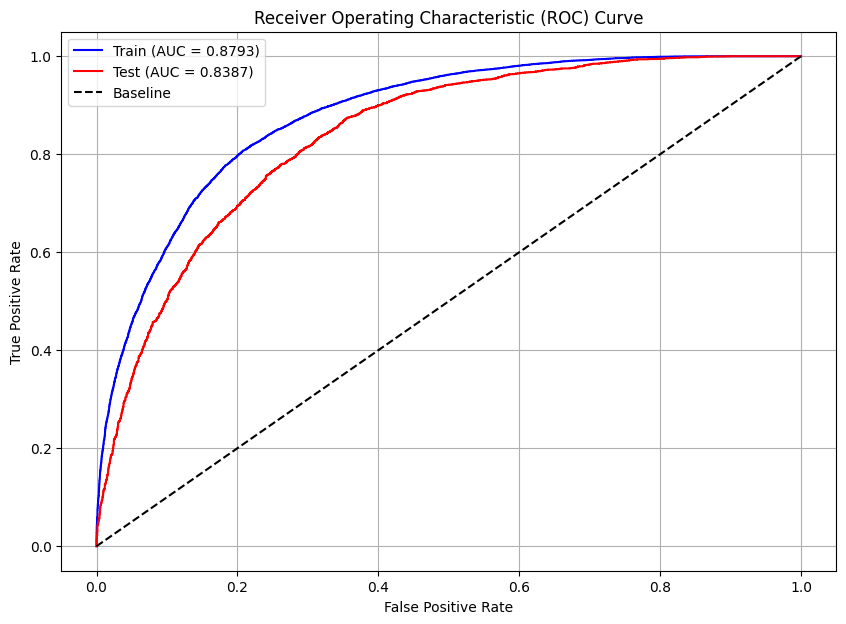

In [ ]:
# Curva ROC
plot_roc_curve(xgb_3year, X_train_3year, X_test_3year, y_train_3year, y_test_3year)

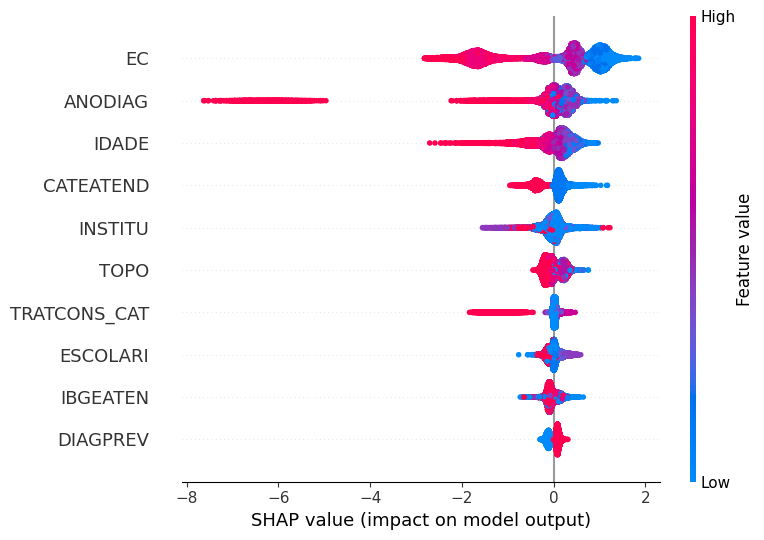

In [ ]:
# Importância das features pelo SHAP
plot_shap_values(xgb_3year, X_train_3year, feat_cols_3year)

## **Sobrevida de 5 anos**

In [ ]:
# Dataset de câncer colorretal
!gdown 1yzI52UDZyac0QGWmKL5Mai1JOqWUTeMQ --quiet

In [ ]:
# Leitura dos dados
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)  # Dimensões do conjunto de dados
df_colo.head(3)  # 3 primeiras linhas do conjunto de dados

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
# Remove os casos com status de sobrevida desconhecido.
# São excluídos os indivíduos que não apresentaram óbito (obito_geral = 0)
# e também não foram classificados como sobreviventes no quinto ano
# (sobrevida_ano5 = 0).
df_colo = df_colo[~((df_colo.obito_geral == 0) & (df_colo.sobrevida_ano5 == 0))].reset_index(drop=True)

# Exibe as dimensões do DataFrame após a remoção dos casos
# com status de sobrevida desconhecido
df_colo.shape

(33872, 49)

In [ ]:
# Divisão dos dados em treino e teste
# Separação das features (X) e label (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (todas as colunas, exceto 'obito_geral')
y = df_colo['obito_geral']  # Label ('obito_geral')

# Divisão do conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% treino, 20% teste
                                                    random_state=seed,  # Reprodutibilidade
                                                    stratify=y)  # Estratificação para manter a proporção das classes

# Tamanhos dos conjuntos após a divisão dos dados
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (27097, 48)
y_train: (27097,)
X_test: (6775, 48)
y_test: (6775,)


In [ ]:
# Salvamento dos datasets
# Cancatenação das features e label
df_treino = pd.concat([X_train, y_train], axis=1)  # Combinação do X_train e y_train em um conjunto de dados
df_teste = pd.concat([X_test, y_test], axis=1)  # Combinação do X_test e y_test em um conjunto de dados

df_treino.to_csv('colorretal_treino.csv', index=False)  # Salva o dataset de treino como 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Salva o dataset de teste como 'colorretal_teste.csv'

In [ ]:
# Leitura dos dados de treino
df_treino = pd.read_csv('colorretal_treino.csv')
print(df_treino.shape)  # Dimensão dos dados
df_treino.head(3)  # 3 primeiras linhas do conjunto de dados

(27097, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,20435,3,60,1,3543907,9,2,C189,IIIB,III,...,0,1,0,0,1,1,0,0,14,1
1,8672,2,56,2,3550308,9,1,C182,II,II,...,0,0,0,0,0,1,1,1,61,0
2,16659,9,61,1,3507001,9,1,C209,III,III,...,0,0,0,0,1,1,0,0,35,1


In [ ]:
# Leitura dos dados de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensão dos dados
df_teste.head(3)  # 3 primeiras linhas do conjunto de dados

(6775, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,612374,3,76,1,3550308,9,2,C199,III,III,...,3,3,0,0,1,1,0,0,20,1
1,612374,2,64,2,3548708,9,2,C209,IIB,II,...,1,2,0,0,0,1,1,1,61,0
2,9385,9,66,2,3550308,2,1,C209,IIA,II,...,2,0,0,0,0,1,1,1,61,0


In [ ]:
# Exclusão das linhas com ULTIDIAG negativo
df_treino = df_treino[df_treino.ULTIDIAG >= 0]

df_treino.shape

(27097, 49)

In [ ]:
# Retirada das colunas que não serão utilizadas como features nos modelos de sobrevida
list_drop = ['ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO', 'HORMONIO',
             'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
             'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
             'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST', 'RRAS_INST',
             'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC', 'obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3',
             'sobrevida_ano5', 'meses_diag', 'obito_geral']

X_train_5year = df_treino.drop(list_drop, axis=1)  # Conjunto de treino
y_train_5year = df_treino.sobrevida_ano5.copy()

X_test_5year = df_teste.drop(list_drop, axis=1)  # Conjunto de teste
y_test_5year = df_teste.sobrevida_ano5.copy()

X_train_5year.shape, y_train_5year.shape, X_test_5year.shape, y_test_5year.shape

((27097, 16), (27097,), (6775, 16), (6775,))

In [ ]:
# Pré-processamento dos conjuntos de treino e teste
X_train_5year, X_test_5year, feat_cols_5year, enc, norm = preprocessing(
    X_train_5year, X_test_5year,
    norm_name='StandardScaler',  # Método de normalização
    return_enc_norm=True,  # Retornar os modelos de codificação e normalização
    random_state=seed)  # Reprodutibilidade

### **XGBoost**


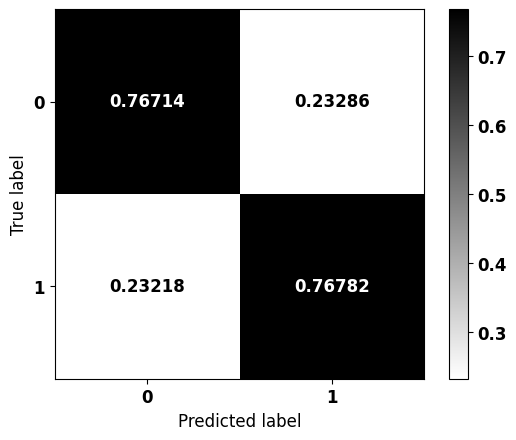


              precision    recall  f1-score   support

           0    0.85769   0.76714   0.80989      4376
           1    0.64383   0.76782   0.70038      2399

    accuracy                        0.76738      6775
   macro avg    0.75076   0.76748   0.75514      6775
weighted avg    0.78196   0.76738   0.77111      6775



In [ ]:
# Define os melhores hiperparâmetros identificados durante o processo
# de otimização para o modelo de classificação de sobrevida em 5 anos
params = {
    'n_estimators': 137,        # Número de árvores utilizadas no modelo
    'max_depth': 5,             # Profundidade máxima das árvores
    'learning_rate': 0.15,      # Taxa de aprendizado do modelo
    'gamma': 0.1,               # Redução mínima da função de perda necessária para dividir um nó
    'min_child_weight': 6,      # Soma mínima dos pesos das observações em um nó filho
    'colsample_bytree': 0.3,    # Proporção de variáveis selecionadas para cada árvore
    'random_state': 1,          # Semente aleatória para garantir reprodutibilidade
    'scale_pos_weight': 1.286   # Peso aplicado à classe positiva para lidar com o desbalanceamento
}

# Inicializa o classificador XGBoost
xgb_5year = XGBClassifier()

# Define os hiperparâmetros otimizados no modelo
xgb_5year.set_params(**params)

# Treina o modelo otimizado utilizando o conjunto de treinamento
# correspondente à classificação de sobrevida em 5 anos
xgb_5year.fit(X_train_5year, y_train_5year)

# Gera e exibe a matriz de confusão para avaliar o desempenho
# do modelo no conjunto de teste
plot_confusion_matrix(xgb_5year, X_test_5year, y_test_5year)

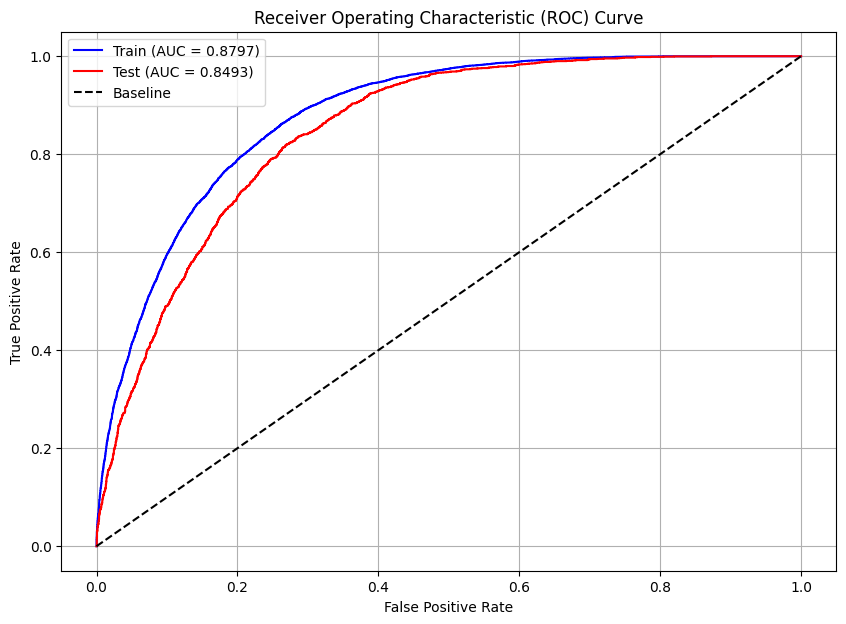

In [ ]:
# Curva ROC
plot_roc_curve(xgb_5year, X_train_5year, X_test_5year, y_train_5year, y_test_5year)

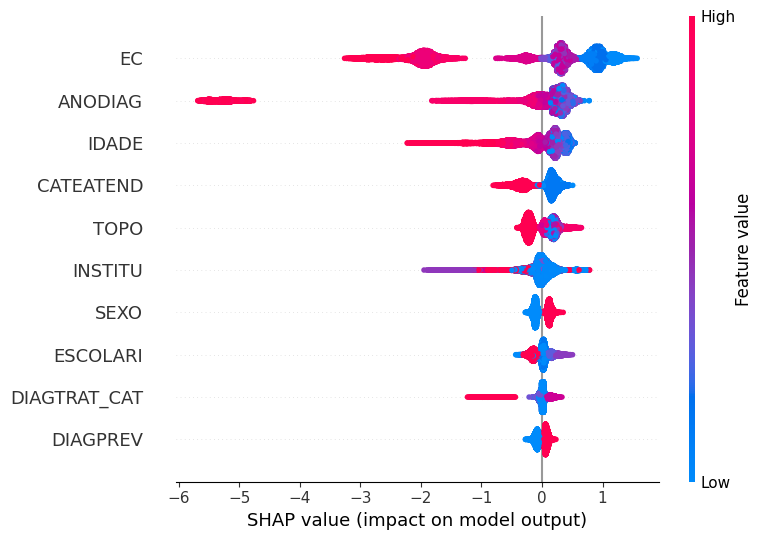

In [ ]:
# Importância das features pelo SHAP
plot_shap_values(xgb_5year, X_train_5year, feat_cols_5year)

# **Comparação dos modelos de sobrevida**

## **Treino e Teste**



In [ ]:
# Dataset de câncer colorretal
!gdown 1yzI52UDZyac0QGWmKL5Mai1JOqWUTeMQ --quiet

In [ ]:
# Leitura dos dados
df_colo = pd.read_csv('colorretal.csv')
print(df_colo.shape)  # Dimensões do conjunto de dados
df_colo.head(3)  # 3 primeiras linhas do conjunto de dados

(44857, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_geral,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag
0,612374,9,91,2,3550308,2,2,C209,IIA,II,...,0,1,0,0,0,0,1,0,0,23
1,8,9,79,2,3550308,9,1,C180,II,II,...,0,0,0,0,0,0,1,1,1,61
2,8,9,59,2,3534401,9,2,C209,II,II,...,0,0,0,1,0,0,1,1,1,61


In [ ]:
# Colunas
df_colo.columns

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO', 'QUIMIO',
       'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS', 'RADIOAPOS',
       'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS', 'ULTINFO',
       'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'ANODIAG', 'DRS', 'RRAS', 'DSCINST',
       'IBGEATEN', 'HABILIT2', 'DRS_INST', 'RRAS_INST', 'ECGRUP_CAT',
       'ULTIDIAG', 'CONSDIAG_CAT', 'TRATCONS_CAT', 'DIAGTRAT_CAT',
       'PRESENCA_META', 'PRESENCA_REC', 'obito_geral', 'obito_cancer',
       'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5', 'meses_diag'],
      dtype='object')

In [ ]:
# Distribuição dos dados de óbito por qualquer razão
df_colo['obito_geral'].value_counts()

,count
obito_geral,
0,22980
1,21877


In [ ]:
# Divisão dos dados em treino e teste
# Separação das features (X) e label (y)
X = df_colo.drop(['obito_geral'], axis=1)  # Features (todas as colunas, exceto 'obito_geral')
y = df_colo['obito_geral']  # Label ('obito_geral')

# Divisão do conjunto de dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  # 80% treino, 20% teste
                                                    random_state=seed,  # Reprodutibilidade
                                                    stratify=y)  # Estratificação para manter a proporção das classes

# Tamanhos dos conjuntos após a divisão dos dados
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_train: (35885, 48)
y_train: (35885,)
X_test: (8972, 48)
y_test: (8972,)


In [ ]:
# Salvamento dos datasets
# Cancatenação das features e label
df_treino = pd.concat([X_train, y_train], axis=1)  # Combinação do X_train e y_train em um conjunto de dados
df_teste = pd.concat([X_test, y_test], axis=1)  # Combinação do X_test e y_test em um conjunto de dados

df_treino.to_csv('colorretal_treino.csv', index=False)  # Salva o dataset de treino como 'colorretal_treino.csv'
df_teste.to_csv('colorretal_teste.csv', index=False)  # Salva o dataset de teste como 'colorretal_teste.csv'

## **Kaplan-Meier**

In [ ]:
# Leitura do conjunto de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensões do conjunto de dados
df_teste.head(3)  # 3 primeiras linhas do conjunto de dados

(8972, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,21636,2,67,1,3516705,2,1,C185,IIIB,III,...,1,0,0,0,0,1,1,1,61,0
1,19488,2,46,2,3552205,2,1,C188,IIIB,III,...,0,0,0,1,0,1,0,0,33,0
2,612374,2,66,2,3534401,9,2,C209,IIA,II,...,0,2,0,0,0,1,1,1,61,0


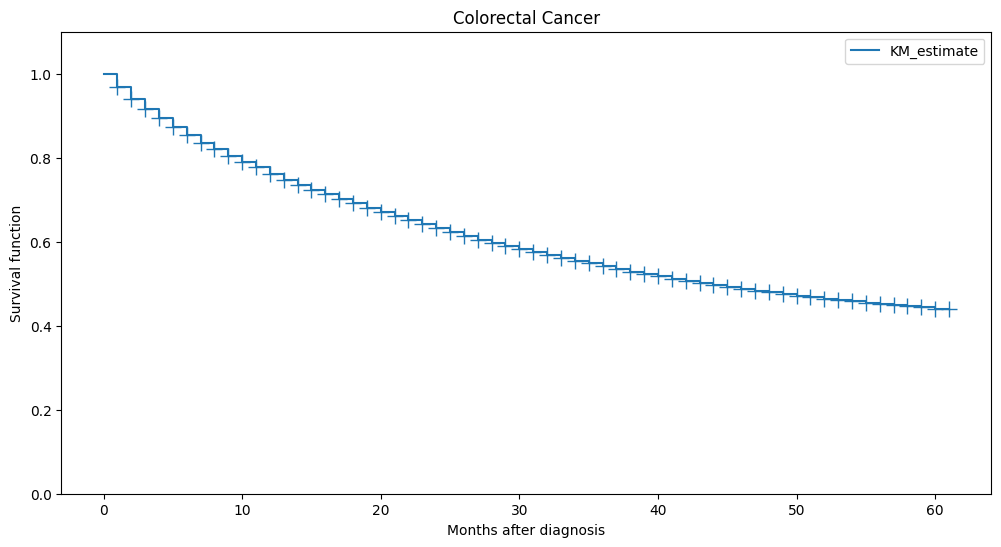

In [ ]:
# Estimador de Kaplan-Meier
# Extração do evento (E) e tempo (T) do conjunto de teste
E = (df_teste.obito_geral == 1)  # Indicador do evento (obito_geral = 1 indica óbito)
T = df_teste.meses_diag  # Tempo até o evento (meses desde o diagnóstico)

title = f'Colorectal Cancer'  # Título do gráfico

kmf = KaplanMeierFitter()  # Inicialização do estimador

# Criação da figura
fig = plt.figure(figsize=(12, 6))
ax = plt.subplot(111)

# Fit e plot da curva de Kaplan-Meier
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True)
ax.set_title(title)  # Adiciona o título
ax.set_xlabel('Meses após diagnóstico')  # Adiciona o nome do eixo x
ax.set_ylabel('Função de sobrevida')  # Adiciona o nome do eixo y
ax.spines['top'].set_visible(False)  # Remove a borda superior
ax.spines['right'].set_visible(False)  # Remove a borda direita
ax.set_xticks(np.arange(0, 71, 12))  # Eixo x com marcadores a cada 12 meses
plt.ylim([0, 1.1])  # Limites do eixo y
plt.show()  # Mostra o gráfico

In [ ]:
# Sobrevida em 1, 3 e 5 anos
kmf.survival_function_.loc[[12, 36, 60]]

,KM_estimate
timeline,
12.0,0.762278
36.0,0.541013
60.0,0.440833


## **Machine Learning Survival**

### **Preparação dos dados para os modelos de sobrevida**

In [ ]:
# Leitura dos dados de treino
df_treino = pd.read_csv('colorretal_treino.csv')
print(df_treino.shape)  # Dimensão dos dados
df_treino.head(3)  # 3 primeiras linhas do conjunto de dados

(35885, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,22128,2,71,1,3549805,2,1,C186,IIA,II,...,0,0,0,0,0,0,0,0,1,1
1,16624,9,73,2,3550308,2,2,C209,IV,IV,...,2,2,1,0,1,1,0,0,26,1
2,16675,4,87,2,3550308,1,1,C209,IVB,IV,...,0,0,1,0,1,1,0,0,13,1


In [ ]:
# Leitura dos dados de teste
df_teste = pd.read_csv('colorretal_teste.csv')
print(df_teste.shape)  # Dimensão dos dados
df_teste.head(3)  # 3 primeiras linhas do conjunto de dados

(8972, 49)


,INSTITU,ESCOLARI,IDADE,SEXO,IBGE,CATEATEND,DIAGPREV,TOPO,EC,ECGRUP,...,TRATCONS_CAT,DIAGTRAT_CAT,PRESENCA_META,PRESENCA_REC,obito_cancer,sobrevida_ano1,sobrevida_ano3,sobrevida_ano5,meses_diag,obito_geral
0,21636,2,67,1,3516705,2,1,C185,IIIB,III,...,1,0,0,0,0,1,1,1,61,0
1,19488,2,46,2,3552205,2,1,C188,IIIB,III,...,0,0,0,1,0,1,0,0,33,0
2,612374,2,66,2,3534401,9,2,C209,IIA,II,...,0,2,0,0,0,1,1,1,61,0


In [ ]:
# Exclusão das linhas com ULTIDIAG negativo
df_treino = df_treino[df_treino.ULTIDIAG >= 0]

df_treino.shape

(35884, 49)

In [ ]:
# y_train e y_test - Óbito e Meses após o diagnóstico
y_train = Surv.from_arrays(df_treino.obito_geral, df_treino.meses_diag)
y_test = Surv.from_arrays(df_teste.obito_geral, df_teste.meses_diag)

In [ ]:
# Retirada das colunas que não serão utilizadas como features nos modelos de sobrevida
list_drop = ['obito_cancer', 'sobrevida_ano1', 'sobrevida_ano3', 'sobrevida_ano5',
             'meses_diag', 'obito_geral', 'ECGRUP', 'NENHUM', 'CIRURGIA', 'RADIO',
             'QUIMIO', 'HORMONIO', 'IMUNO', 'OUTROS', 'NENHUMAPOS', 'CIRURAPOS',
             'RADIOAPOS', 'QUIMIOAPOS', 'HORMOAPOS', 'IMUNOAPOS', 'OUTROAPOS',
             'ULTINFO', 'CONSDIAG', 'TRATCONS', 'DIAGTRAT', 'RRAS', 'DSCINST',
             'RRAS_INST', 'ECGRUP_CAT', 'ULTIDIAG', 'CONSDIAG_CAT', 'PRESENCA_META',
             'PRESENCA_REC']

X_train = df_treino.drop(list_drop, axis=1)  # Conjunto de treino

X_test = df_teste.drop(list_drop, axis=1)  # Conjunto de validação

In [ ]:
# Pré-processamento dos conjuntos de treino e teste
X_train, X_test, feat_cols, enc, norm = preprocessing(X_train, X_test,
                                                      norm_name='StandardScaler',  # Método de normalização
                                                      return_enc_norm=True,  # Retornar os modelos de codificação e normalização
                                                      random_state=seed)  # Reprodutibilidade

# Tamanho final dos dados de treinamento e teste
X_train.shape, X_test.shape

((35884, 16), (8972, 16))

In [ ]:
# Features selecionadas
feat_cols

Index(['INSTITU', 'ESCOLARI', 'IDADE', 'SEXO', 'IBGE', 'CATEATEND', 'DIAGPREV',
       'TOPO', 'EC', 'ANODIAG', 'DRS', 'IBGEATEN', 'HABILIT2', 'DRS_INST',
       'TRATCONS_CAT', 'DIAGTRAT_CAT'],
      dtype='object')

### **Modelos**

**RSF**

In [ ]:
rsf = colo['rsf']
rsf

,n_estimators,116
,max_depth,10
,min_samples_split,9
,min_samples_leaf,9
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,bootstrap,False
,oob_score,False
,n_jobs,None
,random_state,1


C-Index Test: 0.7547371017603656
C-Index Train: 0.7797215136399612

C-Index IPCW Test: 0.7489074752081798
C-Index IPCW Train: 0.7734233170546442

Integrated Brier Score (IBS): 0.1564607924057264

Brier Score:
    > 1 year = 0.13744132278481827
    > 3 years = 0.17567015830959912
    > 5 years = 0.17596705641278645



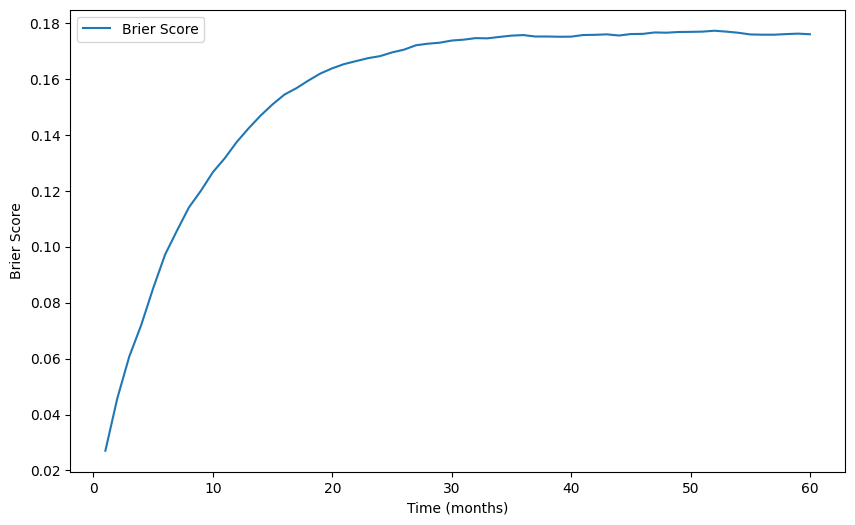

In [ ]:
# rsf = RandomSurvivalForest(bootstrap=False, max_depth=10, max_features='log2',
#                      min_samples_leaf=9, min_samples_split=9, n_estimators=116,
#                      random_state=1)
# rsf.fit(X_train, y_train)

# Métrics para o melhor modelo RSF
# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {rsf.score(X_test, y_test)}')
print(f'C-Index Train: {rsf.score(X_train, y_train)}\n')

# Cálculo do C-Index IPCW e Brier Score
c_index_ipcw_brier_score(rsf, X_train, y_train, X_test, y_test, save=True)

Mean AUC: 0.81974



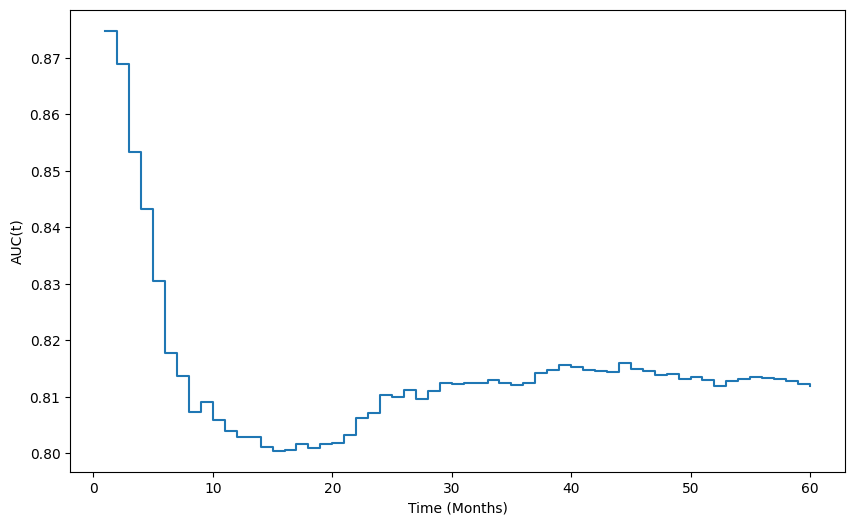

In [ ]:
# Seleciona os tempos únicos observados pelo modelo, removendo o último valor
# Essa remoção pode ser útil para evitar problemas em métricas avaliadas no limite máximo do seguimento
times = rsf.unique_times_[:-1]

# Prediz a função de risco acumulado para os pacientes do conjunto de teste
# return_array=False retorna uma lista de funções, uma para cada paciente
est = rsf.predict_cumulative_hazard_function(X_test, return_array=False)

# Avalia a função de risco acumulado de cada paciente nos tempos definidos em 'times'
model_pred = np.vstack([chf(times) for chf in est])

# Calcula a AUC tempo-dependente usando:
# - times: tempos em que a métrica será avaliada
# - model_pred: predições de risco acumulado dos pacientes ao longo do tempo
# - y_train: dados de sobrevida do conjunto de treino, usados como referência para lidar com censura
# - y_test: dados de sobrevida do conjunto de teste, usados para avaliar o desempenho
# save=True indica que o resultado ou gráfico gerado pela função será salvo
auc_time_dependent(times, model_pred, y_train, y_test, save=True)

**Gradient Boosting Survival**

In [ ]:
gb = colo['gb']
gb

,loss,'coxph'
,learning_rate,0.2
,n_estimators,111
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,5
,min_samples_leaf,6
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,random_state,1


C-Index Test: 0.7588309162059692
C-Index Train: 0.7769290502442211

C-Index IPCW Test: 0.7525671954132044
C-Index IPCW Train: 0.7699414656611409

Integrated Brier Score (IBS): 0.15518065181192547

Brier Score:
    > 1 year = 0.13696842471438048
    > 3 years = 0.17350604846071546
    > 5 years = 0.17530808938267675



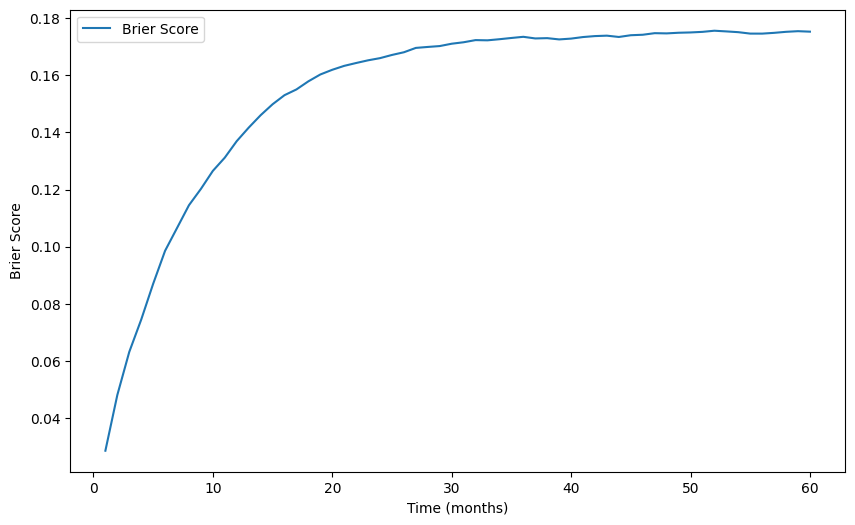

In [ ]:
# gb = GradientBoostingSurvivalAnalysis(learning_rate=0.2, max_depth=5,
#                                  max_features=0.5, min_samples_leaf=6,
#                                  min_samples_split=5, n_estimators=111,
#                                  random_state=1, subsample=0.9)
# gb.fit(X_train, y_train)

# Métrics para o melhor modelo GBSA
# Print do C-index para os conjuntos de teste e de treinamento
print(f'C-Index Test: {gb.score(X_test, y_test)}')
print(f'C-Index Train: {gb.score(X_train, y_train)}\n')

# Cálculo do C-Index IPCW e Brier Score
c_index_ipcw_brier_score(gb, X_train, y_train, X_test, y_test, save=True)

Mean AUC: 0.80372



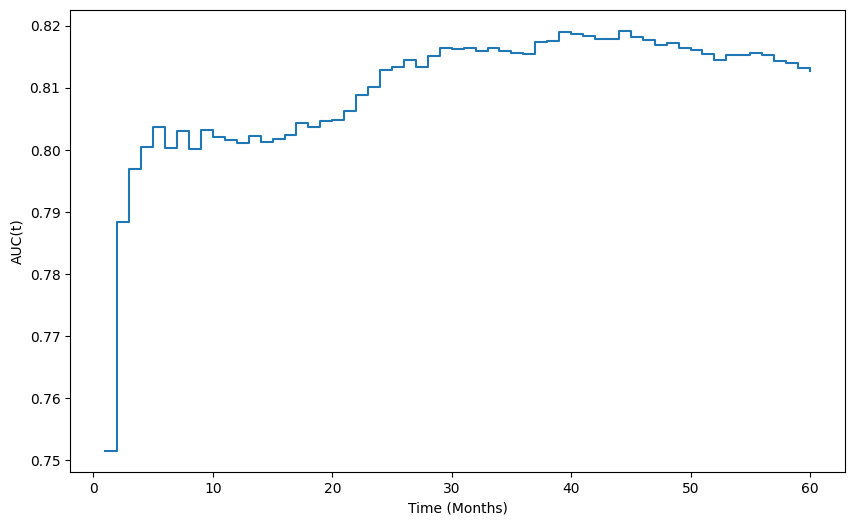

In [ ]:
# Seleciona os tempos únicos observados pelo modelo, removendo o último valor
# Essa remoção pode ser útil para evitar problemas em métricas avaliadas no limite máximo do seguimento
times = gb.unique_times_[:-1]

# Prediz a função de risco acumulado para os pacientes do conjunto de teste
# return_array=False retorna uma lista de funções, uma para cada paciente
est_gb = gb.predict_cumulative_hazard_function(X_test, return_array=False)

# Avalia a função de risco acumulado de cada paciente nos tempos definidos em 'times'
model_pred = np.vstack([chf(times) for chf in est_gb])

# Calcula a AUC tempo-dependente usando:
# - times: tempos em que a métrica será avaliada
# - model_pred: predições de risco acumulado dos pacientes ao longo do tempo
# - y_train: dados de sobrevida do conjunto de treino, usados como referência para lidar com censura
# - y_test: dados de sobrevida do conjunto de teste, usados para avaliar o desempenho
# save=True indica que o resultado ou gráfico gerado pela função será salvo
auc_time_dependent(times, model_pred, y_train, y_test, save=True)

**Survival SVM**

In [ ]:
ssvm = colo['ssvm']
ssvm

,alpha,1
,rank_ratio,1.0
,fit_intercept,False
,max_iter,20
,verbose,False
,tol,None
,optimizer,'avltree'
,random_state,1
,timeit,False


In [ ]:
# ssvm = FastSurvivalSVM(optimizer='avltree', random_state=1)
# ssvm.fit(X_train, y_train)

# Métrics para o melhor modelo SSVM
# Print do C-index para os conjuntos de teste e de treinamento
print('C-Index')
print(f'> Test: {ssvm.score(X_test, y_test)}')
print(f'> Train: {ssvm.score(X_train, y_train)}')

# Cálculo do C-Index IPCW
surv_risks = ssvm.predict(X_test)
c_index_ipcw = concordance_index_ipcw(y_train, y_test, surv_risks)

surv_risks_train = ssvm.predict(X_train)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, surv_risks_train)

print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')
print(f'> Train: {c_index_ipcw_train[0]}')

C-Index
> Test: 0.7088418088812972
> Train: 0.7140363897668406

C-Index IPCW
> Test: 0.7035689517806477
> Train: 0.7080728430532487


Mean AUC: 0.74584



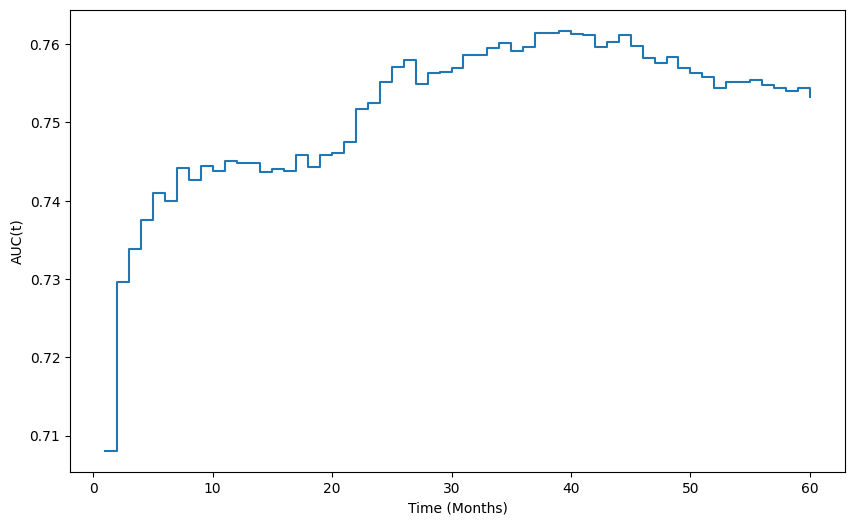

In [ ]:
# Define os tempos em que a AUC tempo-dependente será avaliada
# Neste caso, utiliza os pontos de tempo previamente definidos em 'time_points'
times = time_points

# Gera as predições do modelo para os pacientes do conjunto de teste
# Para alguns modelos de sobrevida, o método predict retorna um escore de risco para cada paciente
model_pred = ssvm.predict(X_test)

# Calcula a AUC tempo-dependente usando:
# - times: tempos em que a métrica será calculada
# - model_pred: predições do modelo, geralmente representando o risco estimado de cada paciente
# - y_train: dados de sobrevida do conjunto de treino, usados como referência para lidar com a censura
# - y_test: dados de sobrevida do conjunto de teste, usados para avaliar o desempenho do modelo
# - save=True: indica que o resultado ou gráfico gerado pela função será salvo
auc_time_dependent(times, model_pred, y_train, y_test, save=True)

Nova versão da adaptação da curva (por calibração do modelo de Cox)

Brier Score at 12 months: 0.1549586946491249
Brier Score at 36 months: 0.19824470036319844
Brier Score at 60 months: 0.2013479972521965

Integrated Brier Score (IBS): 0.1773698437603265


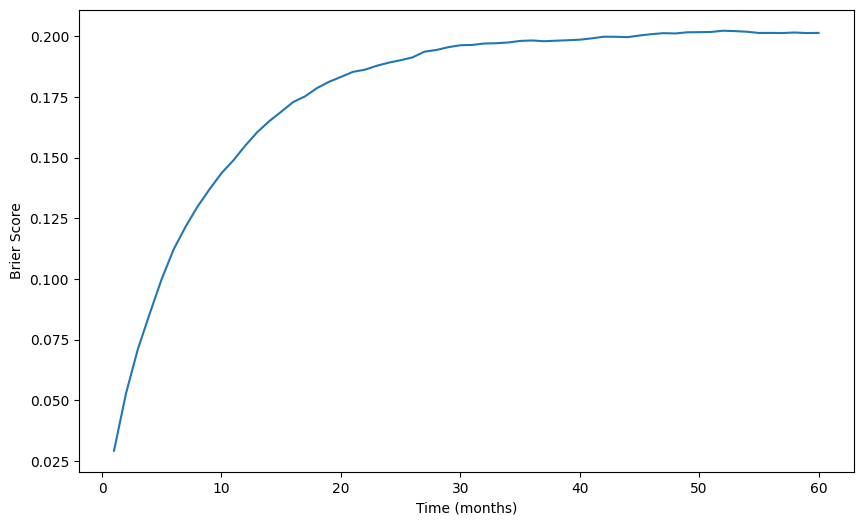

In [ ]:
# Importa o modelo de riscos proporcionais de Cox e a função
# utilizada para representar dados de sobrevida
from lifelines import CoxPHFitter
from sksurv.util import Surv

# Prepara o DataFrame para o treinamento do modelo de Cox
# Extrai o indicador de ocorrência do evento a partir dos dados de teste
event = y_test["event"]

# Extrai o tempo de sobrevida a partir dos dados de teste
time = y_test["time"]

# Cria um DataFrame contendo o tempo de sobrevida, o indicador de evento
# e os escores de risco previstos pelo Survival SVM
df_cox = pd.DataFrame({"time": time, "event": event, "ssvm_score": surv_risks})

# Ajusta o modelo de Cox utilizando o escore previsto pelo Survival SVM
# como variável explicativa
cox = CoxPHFitter()

cox.fit(df_cox, duration_col="time", event_col="event")

# Gera as curvas de sobrevida individuais para cada paciente.
# Cada coluna da matriz representa a função de sobrevida de um indivíduo.
surv_funcs = cox.predict_survival_function(df_cox)

# Remove a última linha correspondente ao mês 61,
# mantendo o período de acompanhamento limitado a 60 meses
surv_funcs.drop(surv_funcs.index[-1], axis=0, inplace=True)

# Calcula a função de sobrevida média ao longo dos indivíduos
surv_ssvm_mean = surv_funcs.mean(axis=1)

# Calcula os Brier Scores e o Integrated Brier Score (IBS)
# Define os pontos de tempo, em meses, utilizados para avaliar
# o desempenho das previsões entre 1 e 60 meses
time_points = np.arange(1, 61, 1)

# Converte as funções de sobrevida para o formato esperado pelas
# funções de cálculo do Brier Score, com cada linha representando um indivíduo
# e cada coluna correspondendo a um ponto no tempo
surv_preds = surv_funcs.values.T

# Calcula o Brier Score para cada ponto de tempo.
# Os dados de treinamento são utilizados para estimar a distribuição
# de censura necessária para o cálculo da métrica.
brier_scores = brier_score(y_train, y_test, surv_preds, time_points)

# Calcula o Integrated Brier Score (IBS), que corresponde à integração
# dos Brier Scores ao longo do período de acompanhamento
ibs = integrated_brier_score(y_train, y_test, surv_preds, time_points)

# Exibe os Brier Scores nos meses 12, 36 e 60
print(f"Brier Score at 12 months: {brier_scores[1][11]}")
print(f"Brier Score at 36 months: {brier_scores[1][35]}")
print(f"Brier Score at 60 months: {brier_scores[1][59]}")

# Exibe o Integrated Brier Score para todo o período de acompanhamento
print(f"\nIntegrated Brier Score (IBS): {ibs}")

# Plota a evolução do Brier Score ao longo do tempo
# Cria a figura e define suas dimensões
plt.figure(figsize=(10, 6))

# Plota os valores do Brier Score para cada mês de acompanhamento
plt.plot(time_points, brier_scores[1])

# Define os rótulos dos eixos
plt.xlabel("Time (months)")
plt.ylabel("Brier Score")

# Exibe o gráfico
plt.show()

**XGBoost - Cox**

In [ ]:
xgb_cox = colo['xgb_cox']
xgb_cox

In [ ]:
# XGBoost-Cox

# Define pesos para as observações do conjunto de treino com base no status do evento
# Pacientes que tiveram o evento recebem peso 1.0. Pacientes censurados recebem peso 0.25
weights = np.where(y_train['event'], 1.0, 0.25)

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino
# y_train['time'] é usado como variável alvo, representando o tempo até o evento ou censura
# weight=weights informa ao modelo os pesos definidos para eventos e censuras
dtrain = xgb.DMatrix(X_train, label=y_train['time'], weight=weights)

# Cria a estrutura DMatrix do XGBoost para o conjunto de teste
# Não é necessário informar o label, pois este conjunto será usado apenas para predição
dtest = xgb.DMatrix(X_test)

# Gera as predições para o conjunto de teste e de treino
y_pred = xgb_cox.predict(dtest)
y_pred_train = xgb_cox.predict(dtrain)

# Calcula o C-Index no conjunto de teste e de treino
c_index = concordance_index_censored(y_test['event'], y_test['time'], y_pred)[0]  # C-Index for test
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], y_pred_train)[0]  # C-Index for train

# Print do C-Index para os conjuntos de teste e de treinamento
print('C-Index')
print(f'> Test: {c_index}')
print(f'> Train: {c_index_train}')

# Calcula o C-Index IPCW no conjunto de teste e de treino
c_index_ipcw = concordance_index_ipcw(y_train, y_test, y_pred)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, y_pred_train)

# Print do C-Index IPCW para os conjuntos de teste e de treinamento
print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')
print(f'> Train: {c_index_ipcw_train[0]}')

C-Index
> Test: 0.7239723543823222
> Train: 0.7372687445273292

C-Index IPCW
> Test: 0.7183988956881996
> Train: 0.7302338923259778


Mean AUC: 0.79375



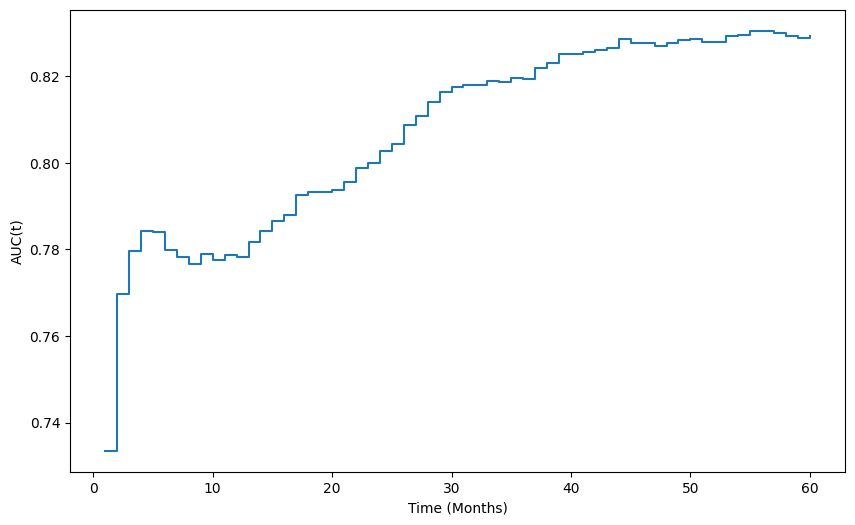

In [ ]:
# Define os tempos em que a AUC tempo-dependente será avaliada
# Neste caso, a avaliação será feita mês a mês, do mês 1 ao mês 60
time_points = np.arange(1, 61, 1)

# Gera as predições do modelo para o conjunto de teste
# Como o modelo está sendo avaliado com XGBoost, a predição é feita a partir do DMatrix 'dtest'
# Em geral, para o objetivo Cox, esses valores representam escores de risco
# Para o objetivo AFT, esses valores podem representar uma estimativa associada ao tempo de sobrevida
y_pred = xgb_cox.predict(dtest)

# Calcula a AUC tempo-dependente usando:
# - time_points: tempos em que a métrica será calculada
# - y_pred: predições do modelo para os pacientes do conjunto de teste
# - y_train: dados de sobrevida do conjunto de treino, usados como referência para lidar com a censura
# - y_test: dados de sobrevida do conjunto de teste, usados para avaliar o desempenho do modelo
# - save=True: indica que o resultado ou gráfico gerado pela função será salvo
auc_time_dependent(time_points, y_pred, y_train, y_test, save=True)

**XGBoost - AFT**

In [ ]:
xgb_aft = colo['xgb_aft']
xgb_aft

In [ ]:
# XGBoost-AFT

# Define pesos para as observações do conjunto de treino com base no status do evento
# Pacientes que tiveram o evento recebem peso 1.0. Pacientes censurados recebem peso 0.65
weights = np.where(y_train['event'], 1.0, 0.65)

# Limites superiores e inferiores do AFT
label_lower_bound = y_train['time']
label_upper_bound = np.where(y_train['event'], y_train['time'], np.inf)

# Cria a estrutura DMatrix do XGBoost para o conjunto de treino
# y_train['time'] é usado como variável alvo, representando o tempo até o evento ou censura
# weight=weights informa ao modelo os pesos definidos para eventos e censuras
dtrain = xgb.DMatrix(X_train,
                     label_lower_bound=label_lower_bound,
                     label_upper_bound=label_upper_bound,
                     weight=weights)

# Cria a estrutura DMatrix do XGBoost para o conjunto de teste
dtest = xgb.DMatrix(X_test)

# Gera as predições para o conjunto de teste e de treino
y_pred = xgb_aft.predict(dtest)
y_pred_train = xgb_aft.predict(dtrain)

# Calcula o C-Index no conjunto de teste e de treino
c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print('C-Index')
print(f'> Test: {c_index}')
print(f'> Train: {c_index_train}')

# Calcula o C-Index IPCW no conjunto de teste e de treino
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)

# Print do C-Index IPCW para os conjuntos de teste e de treinamento
print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')
print(f'> Train: {c_index_ipcw_train[0]}')

C-Index
> Test: 0.7617986988966732
> Train: 0.7811839221420257

C-Index IPCW
> Test: 0.7531615637628547
> Train: 0.7712038798077203


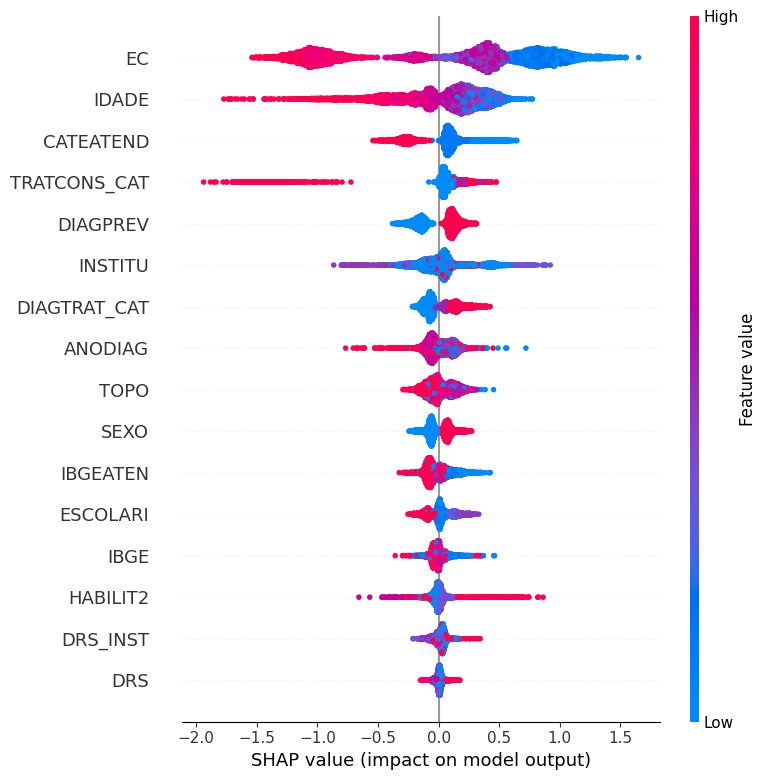

In [ ]:
# Melhores features pelo SHAP
explainer = shap.TreeExplainer(best)

# Calcula os valores SHAP para os pacientes do conjunto de teste
shap_values = explainer.shap_values(X_test)

# Gera o gráfico resumo do SHAP
shap.summary_plot(shap_values, X_test, feature_names=feat_cols, show=False)

# Salva a figura
plt.savefig('colorectal.eps')

Gráfico - Permutation Importance e SHAP

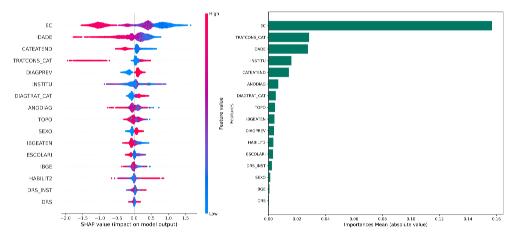

In [ ]:
# Importa as bibliotecas necessárias para análise de importância das variáveis,
# visualização dos resultados e manipulação das imagens
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.image as mpimg

# Calcula a importância das variáveis por permutação para o modelo XGBoost-AFT,
# utilizando o conjunto de teste como base para avaliar a contribuição de cada variável
permutation_importance = calculate_permutation_importance_xgb(
    xgb_aft,
    X_test,
    y_test,
    feat_cols,
    random_state=seed
)

# Cria o TreeExplainer do SHAP para o modelo XGBoost-AFT selecionado
explainer = shap.TreeExplainer(xgb_aft)

# Calcula os valores SHAP para as observações do conjunto de teste.
# Os valores SHAP representam a contribuição de cada variável para as predições do modelo.
shap_values = explainer.shap_values(X_test)

# Gera o gráfico de resumo dos valores SHAP e o mantém temporariamente em memória
# para posterior salvamento como arquivo de imagem
shap.summary_plot(shap_values, X_test, feature_names=feat_cols, show=False)

# Ajusta automaticamente o espaçamento dos elementos do gráfico
plt.tight_layout()

# Salva o gráfico de resumo SHAP em alta resolução
plt.savefig("shap_plot.png", dpi=600, bbox_inches='tight')

# Fecha a figura para liberar memória
plt.close()

# Verifica se o nome do índice do DataFrame corresponde a uma variável.
# Caso exista, converte o índice em uma coluna
if permutation_importance.index.name is not None:
    permutation_importance = permutation_importance.reset_index()

# Cria uma coluna contendo os nomes das variáveis para utilização no gráfico
permutation_importance['features'] = permutation_importance.index

# Cria a figura para representar graficamente a importância das variáveis
# obtida pelo método de importância por permutação
fig, ax = plt.subplots(figsize=(10, 8))

# Ordena as variáveis de acordo com a importância média, da maior para a menor
permutation_importance_sorted = permutation_importance.sort_values(
    'importances_mean',
    ascending=False
)

# Cria um gráfico de barras horizontais utilizando o valor absoluto
# da importância média de cada variável
ax.barh(permutation_importance_sorted['features'],
        permutation_importance_sorted['importances_mean'].abs(),
        color='#007863')

# Define os rótulos dos eixos
ax.set_xlabel('Importância média (valor absoluto)', fontsize=12)

ax.set_ylabel('Variáveis', fontsize=12)

# Define o espaçamento da figura
plt.tight_layout()

# Salva o gráfico de importância por permutação em alta resolução
plt.savefig("bar_plot.png", dpi=600, bbox_inches='tight')

# Fecha a figura para liberar memória
plt.close()

# Abre os dois gráficos previamente salvos e os converte para o modo RGB
# para permitir sua combinação em uma única imagem
img1 = Image.open("shap_plot.png").convert("RGB")
img2 = Image.open("bar_plot.png").convert("RGB")

# Verifica se as imagens possuem a mesma altura.
# Caso contrário, redimensiona a segunda imagem para igualar sua altura à primeira
if img1.height != img2.height:
    img2 = img2.resize((img2.width, img1.height))

# Define as dimensões da imagem final combinada
max_height = max(img1.height, img2.height)
total_width = img1.width + img2.width

# Cria uma nova imagem com fundo branco para acomodar os dois gráficos
combined_img = Image.new('RGB', (total_width, max_height), color=(255, 255, 255))

# Insere o gráfico SHAP no lado esquerdo da imagem final
combined_img.paste(img1, (0, 0))

# Insere o gráfico de importância por permutação no lado direito
combined_img.paste(img2, (img1.width, 0))

# Salva a imagem final contendo os dois gráficos lado a lado
combined_img.save("PI_SHAP_colorectal_charts.png", dpi=(300, 300), quality=95,
                  optimize=True)

# Salva a imagem no formato EPS, caso seja necessário utilizar
# o gráfico em documentos científicos ou publicações
# combined_img.save(
#     "PI_SHAP_colorectal_charts.eps",
#     dpi=(300, 300),
#     quality=95,
#     optimize=True
# )

# Carrega a imagem combinada para visualização no ambiente Python
img = mpimg.imread("PI_SHAP_colorectal_charts.png")

# Exibe a imagem combinada
plt.imshow(img)

# Remove os eixos para apresentar somente os gráficos
plt.axis('off')

# Exibe a figura
plt.show()

**LightGBM**

In [ ]:
# Pacientes que tiveram o evento recebem peso 1.0. Pacientes censurados recebem peso 0.15
weights = np.where(y_train['event'], 1.0, 0.15)

# Define os parâmetros do modelo LightGBM para análise de sobrevida
params = {'n_estimators': 110, 'learning_rate': 0.11, 'max_depth': 5,
          'num_leaves': 23, 'min_child_samples': 14, 'subsample': 0.6,
          'colsample_bytree': 0.5, 'reg_alpha': 10.0, 'reg_lambda': 0.01}

params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'seed': seed,
    'verbose': -1,
    'n_jobs': -1
    })

# Cria a estrutura DMatrix do LightGBM para o conjunto de treino
dtrain = lgb.Dataset(X_train, label=y_train['time'], weight=weights)

# Treina o modelo LightGBM usando o conjunto de treino
lgbm = lgb.train(params, dtrain, num_boost_round=100)

# Gera as predições para o conjunto de teste e de treino
y_pred = lgbm.predict(X_test)
y_pred_train = lgbm.predict(X_train)

# Calcula o C-Index no conjunto de teste e de treino
c_index = concordance_index_censored(y_test['event'], y_test['time'], -y_pred)[0]
c_index_train = concordance_index_censored(y_train['event'], y_train['time'], -y_pred_train)[0]

# Print do C-Index para os conjuntos de teste e de treinamento
print('C-Index')
print(f'> Test: {c_index}')
print(f'> Train: {c_index_train}')

# Cálculo do C-Index IPCW
c_index_ipcw = concordance_index_ipcw(y_train, y_test, -y_pred)
c_index_ipcw_train = concordance_index_ipcw(y_train, y_train, -y_pred_train)

# Print do C-Index IPCW para os conjuntos de teste e de treinamento
print('\nC-Index IPCW')
print(f'> Test: {c_index_ipcw[0]}')
print(f'> Train: {c_index_ipcw_train[0]}')

C-Index
> Test: 0.7274680720718807
> Train: 0.7440293719234166

C-Index IPCW
> Test: 0.7210504695773766
> Train: 0.7344669243598438


# **Curvas**

In [ ]:
# Realiza as predições de sobrevida em 1 ano utilizando o classificador XGBoost
pred_1year = xgb_1year.predict(X_test_1year)

# Calcula a proporção de indivíduos classificados como sobreviventes
# em 1 ano
prop_1year = pred_1year.sum() / X_test_1year.shape[0]

# Realiza as predições de sobrevida em 3 anos utilizando o classificador XGBoost
pred_3year = xgb_3year.predict(X_test_3year)

# Calcula a proporção de indivíduos classificados como sobreviventes
# em 3 anos
prop_3year = pred_3year.sum() / X_test_3year.shape[0]

# Realiza as predições de sobrevida em 5 anos utilizando o classificador XGBoost
pred_5year = xgb_5year.predict(X_test_5year)

# Calcula a proporção de indivíduos classificados como sobreviventes
# em 5 anos
prop_5year = pred_5year.sum() / X_test_5year.shape[0]

# Exibe as estimativas de sobrevida em 1, 3 e 5 anos,
# calculadas como a proporção de indivíduos classificados
# como sobreviventes pelo respectivo modelo
print(f'1-year survival - XGBoost Classifier: {prop_1year:.4f}')
print(f'3-year survival - XGBoost Classifier: {prop_3year:.4f}')
print(f'5-year survival - XGBoost Classifier: {prop_5year:.4f}')

1-year survival - XGBoost Classifier: 0.6244
3-year survival - XGBoost Classifier: 0.4975
5-year survival - XGBoost Classifier: 0.4223


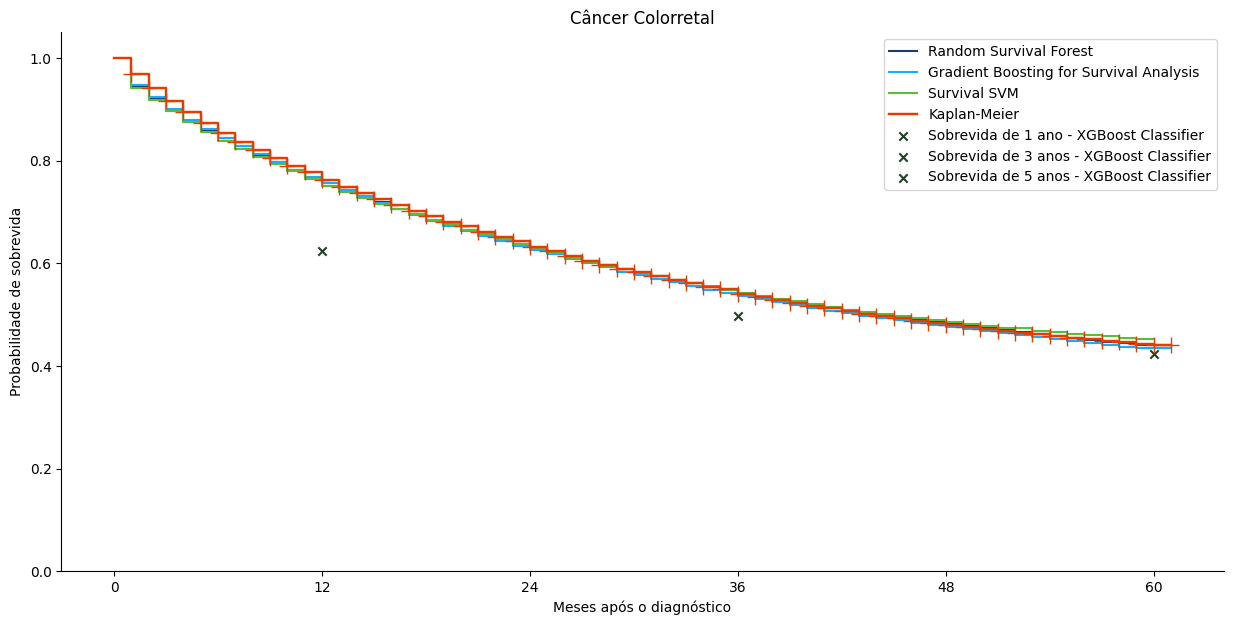

In [ ]:
# Curvas de sobrevida

# Cria a figura e define suas dimensões
fig = plt.figure(figsize=(15, 7))

# Cria o eixo utilizado para construção do gráfico
ax = plt.subplot(111)

# Define o indicador de ocorrência do evento.
# Nesse caso, obito_geral = 1 indica a ocorrência do óbito
E = (df_teste.obito_geral == 1)

# Define o tempo até o evento, em meses após o diagnóstico
T = df_teste.meses_diag

# Define as cores utilizadas para representar cada modelo e estimativa
colors = ['#E53D00', '#15ADFF', '#1B3B6F', '#5FBB3B', '#204026']

# Obtém os tempos únicos utilizados pelo modelo Random Survival Forest
times = rsf.unique_times_

# Define o estilo das linhas das curvas
lstyle = 'solid'

# Calcula as funções de sobrevida previstas pelo Random Survival Forest
# para as observações do conjunto de teste
surv_rsf = rsf.predict_survival_function(X_test, return_array=True)

# Calcula a função de sobrevida média entre todas as observações do conjunto de teste
surv_rsf_mean = surv_rsf.mean(axis=0)

# Adiciona a curva de sobrevida média do Random Survival Forest ao gráfico
ax.step(
    times,
    surv_rsf_mean,
    linestyle=lstyle,
    color=colors[2],
    label='Random Survival Forest'
)

# Calcula as funções de sobrevida previstas pelo Gradient Boosting
# para as observações do conjunto de teste
surv_gb = gb.predict_survival_function(X_test, return_array=True)

# Calcula a função de sobrevida média entre todas as observações do conjunto de teste
surv_gb_mean = surv_gb.mean(axis=0)

# Adiciona a curva de sobrevida média do Gradient Boosting ao gráfico
ax.step(
    times,
    surv_gb_mean,
    linestyle=lstyle,
    color=colors[1],
    label='Gradient Boosting for Survival Analysis'
)

# Adiciona a curva de sobrevida média prevista pelo Survival SVM ao gráfico.
# A última posição de times é removida para compatibilizar as dimensões
# com as predições do modelo
ax.step(
    times[:-1],
    surv_ssvm_mean,
    linestyle=lstyle,
    color=colors[3],
    label='Survival SVM'
)

# Ajusta o estimador de Kaplan-Meier aos tempos de sobrevida e aos
# indicadores de ocorrência do evento e adiciona sua curva ao gráfico.
# O intervalo de confiança é desativado e as observações censuradas são exibidas.
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True,
                        label='Kaplan-Meier', color=colors[0], linewidth=1.75)

# Realiza as predições de sobrevida em 1 ano utilizando o classificador XGBoost
pred_1year = xgb_1year.predict(X_test_1year)

# Calcula a proporção de indivíduos classificados como sobreviventes em 1 ano
prop_1year = pred_1year.sum() / X_test_1year.shape[0]

# Adiciona ao gráfico a estimativa de sobrevida em 1 ano
# obtida pelo classificador XGBoost
ax.scatter(12, prop_1year, label='Sobrevida de 1 ano - XGBoost Classifier',
           color=colors[4], marker='x')

# Realiza as predições de sobrevida em 3 anos utilizando o classificador XGBoost
pred_3year = xgb_3year.predict(X_test_3year)

# Calcula a proporção de indivíduos classificados como sobreviventes em 3 anos
prop_3year = pred_3year.sum() / X_test_3year.shape[0]

# Adiciona ao gráfico a estimativa de sobrevida em 3 anos
# obtida pelo classificador XGBoost
ax.scatter(36, prop_3year, label='Sobrevida de 3 anos - XGBoost Classifier',
           color=colors[4], marker='x')

# Realiza as predições de sobrevida em 5 anos utilizando o classificador XGBoost
pred_5year = xgb_5year.predict(X_test_5year)

# Calcula a proporção de indivíduos classificados como sobreviventes em 5 anos
prop_5year = pred_5year.sum() / X_test_5year.shape[0]

# Adiciona ao gráfico a estimativa de sobrevida em 5 anos
# obtida pelo classificador XGBoost
ax.scatter(60, prop_5year, label='Sobrevida de 5 anos - XGBoost Classifier',
           color=colors[4], marker='x')

# Define o título do gráfico
title = f'Câncer Colorretal'
ax.set_title(title)

# Define os rótulos dos eixos
ax.set_xlabel('Meses após o diagnóstico')
ax.set_ylabel('Probabilidade de sobrevida')

# Remove as bordas superior e direita do gráfico
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Define marcações no eixo x a cada 12 meses
plt.xticks(np.arange(0, rsf.unique_times_[-1] + 11, 12))

# Define os limites do eixo y para representar probabilidades entre 0 e 1
plt.ylim([0, 1.05])

# Exibe a legenda com a identificação das curvas e estimativas
plt.legend()

# Salva o gráfico no formato JPG
plt.savefig('curvas_pontos.jpg')

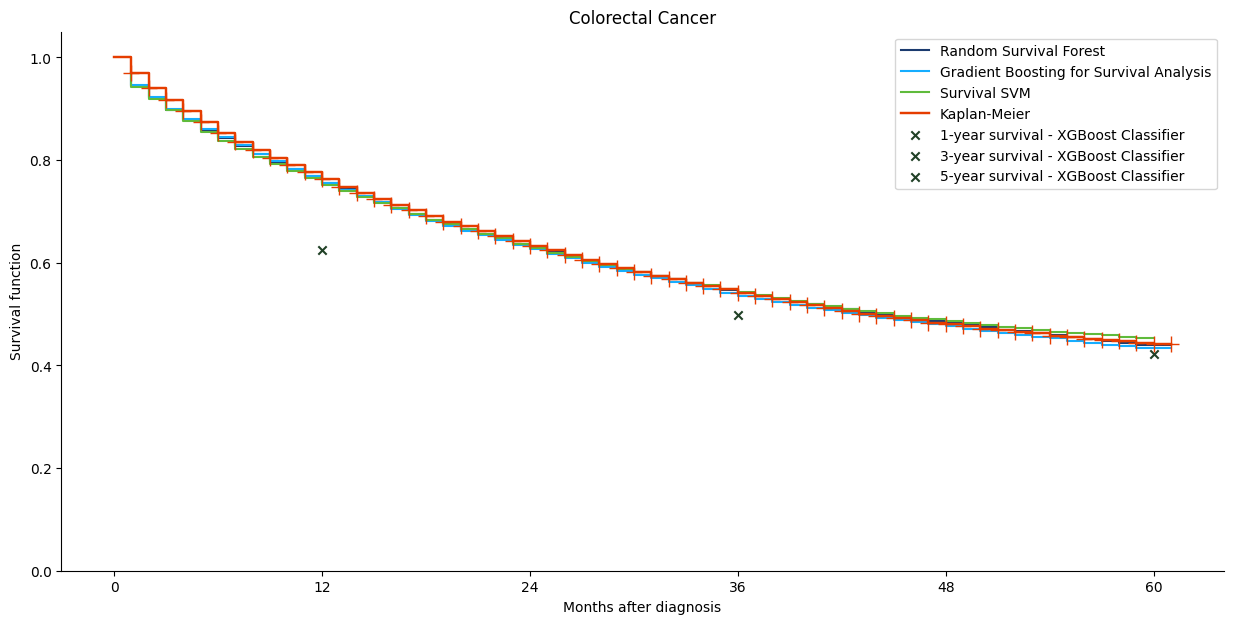

In [ ]:
# Curvas de sobrevida

# Cria a figura e define suas dimensões
fig = plt.figure(figsize=(15, 7))

# Cria um eixo para a construção do gráfico
ax = plt.subplot(111)

# Define o indicador de ocorrência do evento.
# Nesse caso, obito_geral = 1 indica ocorrência do óbito
E = (df_teste.obito_geral == 1)

# Define o tempo até o evento, em meses após o diagnóstico
T = df_teste.meses_diag

# Define as cores utilizadas para diferenciar as curvas e estimativas
colors = ['#E53D00', '#15ADFF', '#1B3B6F', '#5FBB3B', '#204026']

# Obtém os tempos únicos utilizados pelo modelo Random Survival Forest
times = rsf.unique_times_

# Define o estilo de linha utilizado para as curvas
lstyle = 'solid'

# Calcula as funções de sobrevida previstas pelo Random Survival Forest
# para todas as observações do conjunto de teste
surv_rsf = rsf.predict_survival_function(X_test, return_array=True)

# Calcula a função de sobrevida média do modelo RSF,
# considerando todas as observações do conjunto de teste
surv_rsf_mean = surv_rsf.mean(axis=0)

# Adiciona a curva de sobrevida média do Random Survival Forest ao gráfico
ax.step(
    times,
    surv_rsf_mean,
    linestyle=lstyle,
    color=colors[2],
    label='Random Survival Forest'
)

# Calcula as funções de sobrevida previstas pelo Gradient Boosting
# para todas as observações do conjunto de teste
surv_gb = gb.predict_survival_function(X_test, return_array=True)

# Calcula a função de sobrevida média do Gradient Boosting
surv_gb_mean = surv_gb.mean(axis=0)

# Adiciona a curva de sobrevida média do Gradient Boosting ao gráfico
ax.step(
    times,
    surv_gb_mean,
    linestyle=lstyle,
    color=colors[1],
    label='Gradient Boosting for Survival Analysis'
)

# Adiciona a curva de sobrevida média prevista pelo Survival SVM
# ao gráfico, utilizando os tempos correspondentes às predições
ax.step(
    times[:-1],
    surv_ssvm_mean,
    linestyle=lstyle,
    color=colors[3],
    label='Survival SVM'
)

# Ajusta o estimador de Kaplan-Meier aos tempos de sobrevida e aos
# indicadores de ocorrência do evento e adiciona sua curva ao gráfico.
# ci_show=False desativa o intervalo de confiança e show_censors=True
# exibe as observações censuradas na curva.
ax = kmf.fit(T, E).plot(ax=ax, ci_show=False, show_censors=True,
                        label='Kaplan-Meier', color=colors[0], linewidth=1.75)

# Realiza as predições de sobrevida em 1 ano utilizando o classificador XGBoost
pred_1year = xgb_1year.predict(X_test_1year)

# Calcula a proporção de indivíduos classificados como sobreviventes
# em 1 ano
prop_1year = pred_1year.sum() / X_test_1year.shape[0]

# Adiciona ao gráfico a estimativa de sobrevida em 1 ano
# obtida pelo classificador XGBoost
ax.scatter(12, prop_1year, label='1-year survival - XGBoost Classifier',
           color=colors[4], marker='x')

# Realiza as predições de sobrevida em 3 anos utilizando o classificador XGBoost
pred_3year = xgb_3year.predict(X_test_3year)

# Calcula a proporção de indivíduos classificados como sobreviventes
# em 3 anos
prop_3year = pred_3year.sum() / X_test_3year.shape[0]

# Adiciona ao gráfico a estimativa de sobrevida em 3 anos
# obtida pelo classificador XGBoost
ax.scatter(36, prop_3year, label='3-year survival - XGBoost Classifier',
           color=colors[4], marker='x')

# Realiza as predições de sobrevida em 5 anos utilizando o classificador XGBoost
pred_5year = xgb_5year.predict(X_test_5year)

# Calcula a proporção de indivíduos classificados como sobreviventes
# em 5 anos
prop_5year = pred_5year.sum() / X_test_5year.shape[0]

# Adiciona ao gráfico a estimativa de sobrevida em 5 anos
# obtida pelo classificador XGBoost
ax.scatter(60, prop_5year, label='5-year survival - XGBoost Classifier',
           color=colors[4], marker='x')

# Define o título do gráfico
title = f'Colorectal Cancer'
ax.set_title(title)

# Define os rótulos dos eixos
ax.set_xlabel('Months after diagnosis')
ax.set_ylabel('Survival function')

# Remove as bordas superior e direita do gráfico para melhorar a visualização
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Define marcações no eixo x a cada 12 meses
plt.xticks(np.arange(0, rsf.unique_times_[-1] + 11, 12))

# Define os limites do eixo y, mantendo a função de sobrevida entre 0 e 1
plt.ylim([0, 1.05])

# Exibe a legenda identificando as curvas e estimativas apresentadas
plt.legend()

# Salva a figura no formato EPS
plt.savefig('colorectal.eps')

In [ ]:
from google.colab import files
files.download("colorectal.eps")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>